In [7]:
from scipy.stats import multivariate_normal as mvn
import numpy as np 
np.set_printoptions(precision=4)

import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['axes.linewidth'] = 3
mpl.rcParams['axes.titlesize'] = 20
mpl.rcParams['axes.labelsize'] = 20
mpl.rcParams['axes.titlepad'] = 8.0
mpl.rcParams['xtick.major.size'] = 6
mpl.rcParams['xtick.major.width'] = 3
mpl.rcParams['xtick.labelsize'] = 20
mpl.rcParams['ytick.major.size'] = 6
mpl.rcParams['ytick.major.width'] = 3
mpl.rcParams['ytick.labelsize'] = 20
mpl.rcParams['lines.markersize'] = 5
mpl.rcParams['legend.fontsize'] = 15



In [8]:
mean1 = np.array([0.35, 0.38])
cov1 = np.array([[0.01, 0.004],[0.004, 0.01]])
w1 = 0.5

mean2 = np.array([0.68, 0.25])
cov2 = np.array([[0.005, -0.003],[-0.003, 0.005]])
w2 = 0.2

mean3 = np.array([0.56, 0.64])
cov3 = np.array([[0.008, 0.0],[0.0, 0.004]])
w3 = 0.3

def pdf(x):
    return (
        w1 * mvn.pdf(x, mean1, cov1) +
        w2 * mvn.pdf(x, mean2, cov2) +
        w3 * mvn.pdf(x, mean3, cov3)
    )

In [9]:
import sys
import os

sys.path.append(os.path.abspath(".."))
from src.ergodic.metric import *

L_list = np.array([1.0, 1.0])

ks = generate_k_vectors(10)
grids, dx, dy = create_grid(L_list, 100)

phi = compute_phi(pdf, ks, grids, dx, dy, L_list)

print(phi[:10])

[ 0.9898  0.0799 -0.7756 -0.063  -0.0555 -0.0292  0.1801  0.0075 -0.0327
  0.0067]


Text(0.5, 1.0, 'Target Distribution')

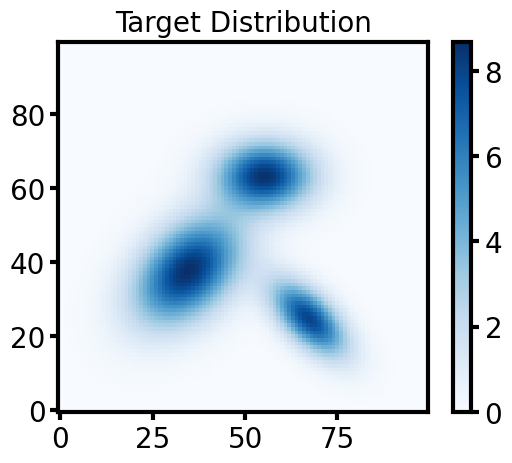

In [ ]:
pdf_vals = pdf(grids).reshape(100, 100)

plt.imshow(pdf_vals, origin="lower", cmap="Blues")
plt.colorbar()
plt.title("Target Distribution")